# Wingert 2026 — ferret auditory cortex encoding subspace

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/explore_wingert2026.ipynb)

This notebook is a **visual smoke test** of the deepSTRF loader for the
**[Wingert et al. 2026](https://doi.org/10.1038/s41593-026-02216-0)**
(*Nat Neurosci*) ferret AC dataset — single-unit Kilosort-sorted spikes
from 67 high-density silicon-probe + Neuropixels recordings spanning
A1, PEG (and ancillary AC / HC), in 4 ferrets passively listening to
natural-sound segments.

We cover:

- the two **stim-duration cohorts** (20 s vs 22 s sessions) and the
  est / val subset semantics;
- per-cell metadata: area, layer, depth, narrow / regular spike-width
  classes, the published `goodpred` flag;
- the **block-diagonal** layout that pools two recording sessions —
  cross-session `(stim, cell)` pairs are NaN sentinels;
- how the **two-probe SLJ032a** recording is exposed as two siteids
  that share one .tgz / one stim set.


## Setup — Google Colab

The cell below installs deepSTRF from source on Colab. On a local
install (`pip install -e .`) it's a no-op.

**Note on data.** The Zenodo archive's `recordings.zip` is **~4.35 GB**;
`download=True` fetches it on demand and skips the much larger
`wav.zip` and `models.zip` that the loader doesn't use. On a
workstation with the data already unpacked, point `WINGERT2026_DATA`
at the directory holding `recordings/` and `cell_list.csv`.


In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


Local environment — assuming deepSTRF is already importable.


## Imports + paths

In [2]:
%matplotlib inline
import os
import warnings
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch

from deepSTRF.datasets.audio import Wingert2026Dataset
from deepSTRF.utils import plot_stim_with_response

# Where the Zenodo dump lives. None → platformdirs cache + download=True
# (4.35 GB recordings.zip + 5 MB cell_list.csv).
DATA = os.environ.get("WINGERT2026_DATA", None)
DOWNLOAD = False  # flip to True on first run if the data isn't local

# Silence the (expected) PRN018b duplicate-drop UserWarning emitted on
# the first .tgz scan — see README §"Note on the PRN018a / PRN018b
# duplicate".
warnings.filterwarnings("ignore", category=UserWarning,
                        module=r"deepSTRF\.datasets\.audio\.wingert2026")


/home/ulysse/miniconda3/envs/deepstrf_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Per-cell metadata — A1 + PEG headline cohort (enumerate-only)

The `_enumerate_only=True` path reads only `cell_list.csv` (~5 MB)
and populates `nrn_meta` / `N_neurons` without touching the per-site
.tgz archives. Useful for fast metadata exploration and sanity checks
before the heavy load. The `area=` and `site=` filters apply at this
stage.


In [3]:
ds_meta = Wingert2026Dataset(
    path=DATA, download=DOWNLOAD, area=["A1", "PEG"], _enumerate_only=True,
)
print(f"A1 + PEG cohort: N = {ds_meta.N_neurons}  ({ds_meta.N_neurons == 2128 + 746})")

# breakdown by area
by_area = Counter(m["area"] for m in ds_meta.nrn_meta)
print(f"  by area: {dict(by_area)}")

# layer breakdown (column is a string like '1-3', '4', '56')
by_layer = Counter(m["layer"] for m in ds_meta.nrn_meta)
print(f"  by layer: {dict(by_layer)}")

# narrow vs broad spike width
by_narrow = Counter(m["narrow"] for m in ds_meta.nrn_meta)
print(f"  by narrow: {dict(by_narrow)}")

# published auditory-responsive flag
goodpred_frac = sum(1 for m in ds_meta.nrn_meta if m["goodpred"]) / len(ds_meta.nrn_meta)
print(f"  goodpred=True fraction: {goodpred_frac:.1%}")


A1 + PEG cohort: N = 2874  (True)
  by area: {'PEG': 746, 'A1': 2128}
  by layer: {'56': 1084, '44': 744, '13': 1046}
  by narrow: {False: 2397, True: 477}
  goodpred=True fraction: 81.3%


### Cell-depth + spike-width distribution

The David lab classifies cells as Regular vs Narrow spiking based on
spike-waveform width (cutoff 0.35 ms for 64-channel silicon probes,
0.375 ms for Neuropixels). Narrow-spiking cells are putative inhibitory
interneurons.


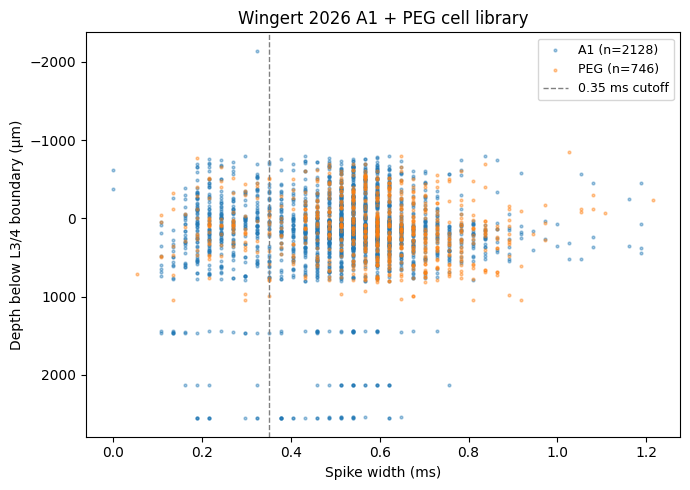

In [4]:
# Depth + spike-width scatter, coloured by area
fig, ax = plt.subplots(figsize=(7, 5))
for area, color in [("A1", "tab:blue"), ("PEG", "tab:orange")]:
    sub = [m for m in ds_meta.nrn_meta
            if m["area"] == area and m["depth"] is not None and m["sw"] is not None]
    ax.scatter(
        [m["sw"] for m in sub], [m["depth"] for m in sub],
        s=4, alpha=0.4, color=color, label=f"{area} (n={len(sub)})",
    )
ax.axvline(0.35, color="grey", lw=1, linestyle="--", label="0.35 ms cutoff")
ax.set_xlabel("Spike width (ms)")
ax.set_ylabel("Depth below L3/4 boundary (μm)")
ax.invert_yaxis()  # superficial layers up
ax.set_title("Wingert 2026 A1 + PEG cell library")
ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()


## 2. Load one small site (CLT027c, 20 cells in A1)

A single-site `Wingert2026Dataset` instance is cheap (~7 s on a
laptop, <500 MB peak RSS). Because every cell saw every stim, the
response grid has **no NaN sentinels** at this scale.


In [5]:
ds = Wingert2026Dataset(path=DATA, download=DOWNLOAD, site="CLT027c")
print(f"site='CLT027c'  N={ds.N_neurons}  S={len(ds.stims)}  F={ds.F}  dt={ds.dt} ms")

# Stim subsets (file-name prefix: STIM_00* = val, STIM_seq* = est)
sub_counts = Counter(m["subset"] for m in ds.stim_meta)
print(f"  subset counts: {dict(sub_counts)}")

# This site is in the 22 s cohort (T=2200 = 1 s pre + 20 s sound + 1 s post)
print(f"  stim shapes: {sorted({tuple(s.shape) for s in ds.stims})}")

# val stim R: this site presented one val stim with R=1, the other with R=2
for i, m in enumerate(ds.stim_meta):
    if m["subset"] == "val":
        print(f"  val stim {m['name']!r} → R={tuple(ds.responses[i][0].shape)[0]}")


Wingert2026 sites:   0%|          | 0/1 [00:00<?, ?it/s]

Wingert2026 sites: 100%|██████████| 1/1 [00:00<00:00, 11.79it/s]

site='CLT027c'  N=20  S=11  F=32  dt=10.0 ms
  subset counts: {'val': 2, 'est': 9}
  stim shapes: [(1, 32, 2200)]
  val stim 'STIM_00seq1.wav' → R=1
  val stim 'STIM_00seq2.wav' → R=2


### One stim, one cell — PSTH + spectrogram

`plot_stim_with_response` ships in `deepSTRF.utils` and accepts either
NumPy arrays or torch tensors. We pick the val stim with the highest
R count (most informative PSTH) and overlay all repeats from the
spike-train cell with the highest mean firing rate.


showing stim 'STIM_00seq2.wav' with R=2
showing cell 'CLT027c-027-1' (area=A1, layer=56, narrow=True)


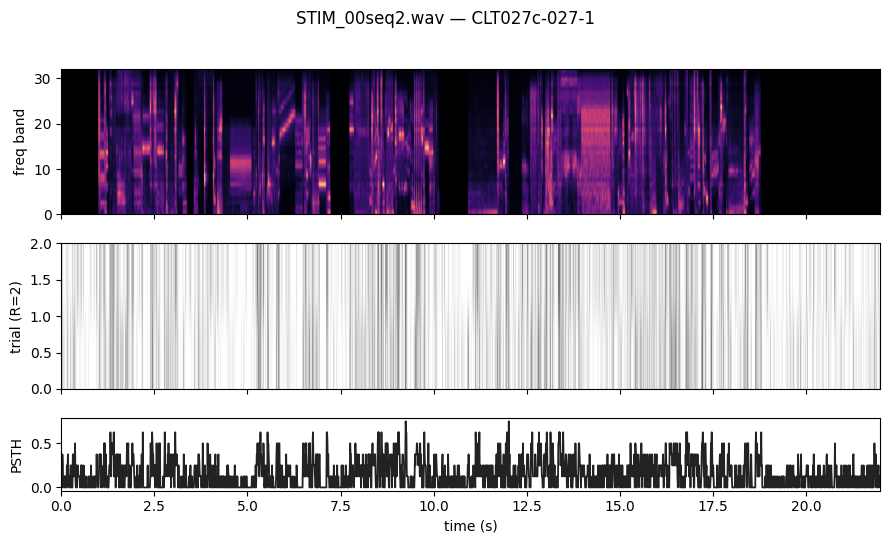

In [6]:
# pick the val stim with the highest R
val_indices = [i for i, m in enumerate(ds.stim_meta) if m["subset"] == "val"]
s_idx = max(val_indices, key=lambda i: ds.responses[i][0].shape[0])
spec = ds.stims[s_idx][0]  # (F, T)
print(f"showing stim {ds.stim_meta[s_idx]['name']!r} with R={ds.responses[s_idx][0].shape[0]}")

# pick the most-active cell across this stim
mean_rates = [ds.responses[s_idx][n].mean().item() for n in range(ds.N_neurons)]
n_idx = int(np.argmax(mean_rates))
cell_meta = ds.nrn_meta[n_idx]
print(f"showing cell {cell_meta['cell_id']!r} (area={cell_meta['area']}, "
      f"layer={cell_meta['layer']}, narrow={cell_meta['narrow']})")

reps = ds.responses[s_idx][n_idx]  # (R, T)
# plot_stim_with_response returns (Figure, axes). It auto-shows the
# raster panel when R > 1 and adds the PSTH overlay.
fig, _ = plot_stim_with_response(
    spec, reps, dt_ms=ds.dt,
    title=f"{ds.stim_meta[s_idx]['name']} — {cell_meta['cell_id']}",
)
plt.show()


## 3. Block-diagonal layout — load two sites at once

Loading more than one site is where the deepSTRF sparse-coverage
paradigm earns its keep. Each cell only has real data for the
~100 stimuli its session presented; for every other session's
stimuli, the loader emits a `(1, 1)` NaN sentinel — and crucially
**all sentinels share the same underlying tensor**, so the in-memory
overhead is one pointer per slot, not a fresh tensor.


In [7]:
ds2 = Wingert2026Dataset(path=DATA, download=DOWNLOAD, site=["CLT027c", "CLT028c"])
print(f"two-site load: N={ds2.N_neurons}  S={len(ds2.stim_meta)}  (sessions: "
      f"{sorted(set(m['session'] for m in ds2.stim_meta))})")

# count real-data slots per session
by_session_real = Counter()
by_session_sentinel = Counter()
for s, smeta in enumerate(ds2.stim_meta):
    for n, nmeta in enumerate(ds2.nrn_meta):
        if ds2.responses[s][n].numel() == 1:
            by_session_sentinel[(smeta["session"], nmeta["session"])] += 1
        else:
            by_session_real[(smeta["session"], nmeta["session"])] += 1
print(f"\nreal-data (stim_session × cell_session) counts:")
for key, n in sorted(by_session_real.items()):
    print(f"  {key}: {n}")
print(f"\nsentinel counts:")
for key, n in sorted(by_session_sentinel.items()):
    print(f"  {key}: {n}")

# Memory regression check: all NaN sentinels share one id
sentinel_ids = {id(t) for row in ds2.responses for t in row if t.numel() == 1}
print(f"\nunique sentinel object ids: {len(sentinel_ids)} (expect 1)")


Wingert2026 sites:   0%|          | 0/2 [00:00<?, ?it/s]

Wingert2026 sites: 100%|██████████| 2/2 [00:01<00:00,  1.52it/s]

Wingert2026 sites: 100%|██████████| 2/2 [00:01<00:00,  1.52it/s]

two-site load: N=77  S=117  (sessions: ['CLT027c', 'CLT028c'])

real-data (stim_session × cell_session) counts:
  ('CLT027c', 'CLT027c'): 220
  ('CLT028c', 'CLT028c'): 6042

sentinel counts:
  ('CLT027c', 'CLT028c'): 627
  ('CLT028c', 'CLT027c'): 2120

unique sentinel object ids: 1 (expect 1)


### Visualising the block-diagonal coverage

The `nrn_masks` `(S, N)` bool tensor (auto-derived from NaN sentinels)
makes the layout immediately visible. The grid is clean block-diagonal:
session A's stims have real data only for session A's cells.


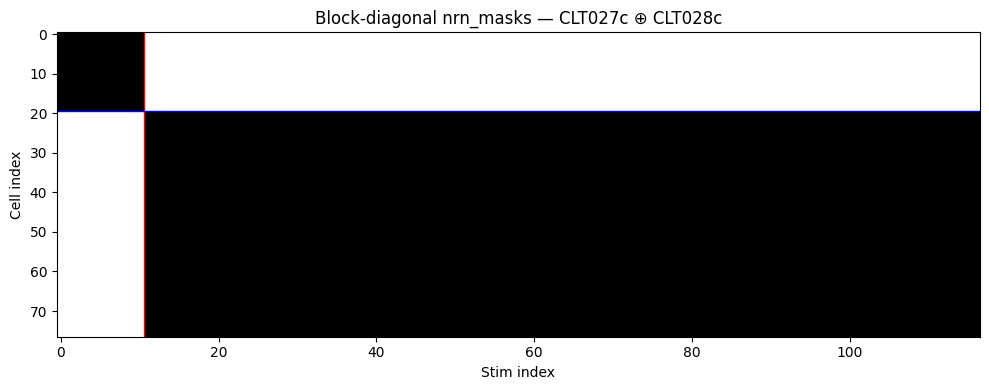

In [8]:
m = ds2.nrn_masks.numpy()  # (S, N) bool
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(m.T, aspect="auto", cmap="Greys", interpolation="nearest")

# Session boundary lines
sess_seen = []
for s, smeta in enumerate(ds2.stim_meta):
    sess = smeta["session"]
    if sess_seen and sess_seen[-1] != sess:
        ax.axvline(s - 0.5, color="red", lw=1)
    sess_seen.append(sess)

cell_seen = []
for n, nmeta in enumerate(ds2.nrn_meta):
    sess = nmeta["session"]
    if cell_seen and cell_seen[-1] != sess:
        ax.axhline(n - 0.5, color="blue", lw=1)
    cell_seen.append(sess)

ax.set_xlabel("Stim index")
ax.set_ylabel("Cell index")
ax.set_title("Block-diagonal nrn_masks — CLT027c ⊕ CLT028c")
plt.tight_layout(); plt.show()


## 4. SLJ032a — one .tgz, two probes, one stim set

The SLJ032a recording used two simultaneously-inserted probes, A and B.
`cell_list.csv` exposes them as separate siteids (`'SLJ032a'` for
probe A's 76 cells, `'SLJ032a-B'` for probe B's 47 cells), but they
share one `.tgz` / one stim set. Loading both probes gives 123 cells
and **one** stim list (no duplication).


In [9]:
ds_slj = Wingert2026Dataset(
    path=DATA, download=DOWNLOAD, site=["SLJ032a", "SLJ032a-B"],
)
print(f"SLJ032a both probes: N={ds_slj.N_neurons}  S={len(ds_slj.stim_meta)}  "
      f"sessions={sorted(set(m['session'] for m in ds_slj.stim_meta))}")

# Site breakdown
by_site = Counter(m["site"] for m in ds_slj.nrn_meta)
print(f"  by site (per-probe): {dict(by_site)}")

# Cell-id format breakdown — probe A and probe B use distinct 4-segment prefixes
by_prefix = Counter("-".join(m["cell_id"].split("-")[:2]) for m in ds_slj.nrn_meta)
print(f"  by cell-id prefix: {dict(by_prefix)}")


Wingert2026 sites:   0%|          | 0/1 [00:00<?, ?it/s]

Wingert2026 sites: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

Wingert2026 sites: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

SLJ032a both probes: N=123  S=56  sessions=['SLJ032a']
  by site (per-probe): {'SLJ032a': 76, 'SLJ032a-B': 47}
  by cell-id prefix: {'SLJ032a-A': 76, 'SLJ032a-B': 47}


## 5. The two duration cohorts

47 sites at `T=2000` bins (20 s sound, no silence flanks) coexist with
21 sites at `T=2200` bins (1 s pre + 20 s sound + 1 s post silence).
The deepSTRF data paradigm handles ragged T natively — collate
zero-pads on the right; models that expect a fixed T can use
`select_stims_by_predicate` to filter to one cohort.


In [10]:
# Enumerate cohorts from the local Phase 2 scan (no full load needed)
ds_a = Wingert2026Dataset(path=DATA, download=DOWNLOAD, area="A1", _enumerate_only=True)
sites = sorted(set(m["session"] for m in ds_a.nrn_meta))
print(f"A1 has cells in {len(sites)} unique recording sessions.")
print("(Stim-duration cohort is property of the .tgz itself; use a load to confirm.)")


A1 has cells in 50 unique recording sessions.
(Stim-duration cohort is property of the .tgz itself; use a load to confirm.)


## What's next

- **Linear / CNN baselines** — the `Fitter` from
  `docs/_source/md/fitter.md` ports to Wingert unchanged; use
  `subset='est'` for train/val and `subset='val'` for held-out
  evaluation. Note the **per-site R variability** for val stims (5–30)
  when reporting cc_norm.
- **Cross-area pooling** — `concat_neural_datasets([a1, peg])` builds
  a 2 874-cell joint dataset for unified-model fitting. Like NAT4, the
  joint dataset is block-diagonal across areas as well as sessions.
- **The published encoding subspace** — the paper's CNN / LN / subspace
  fits live in `models.zip` on Zenodo. They are NEMS-format and not
  loaded by deepSTRF; re-fitting against the deepSTRF model zoo (Linear,
  StateNet, Transformer) is the natural next step.
